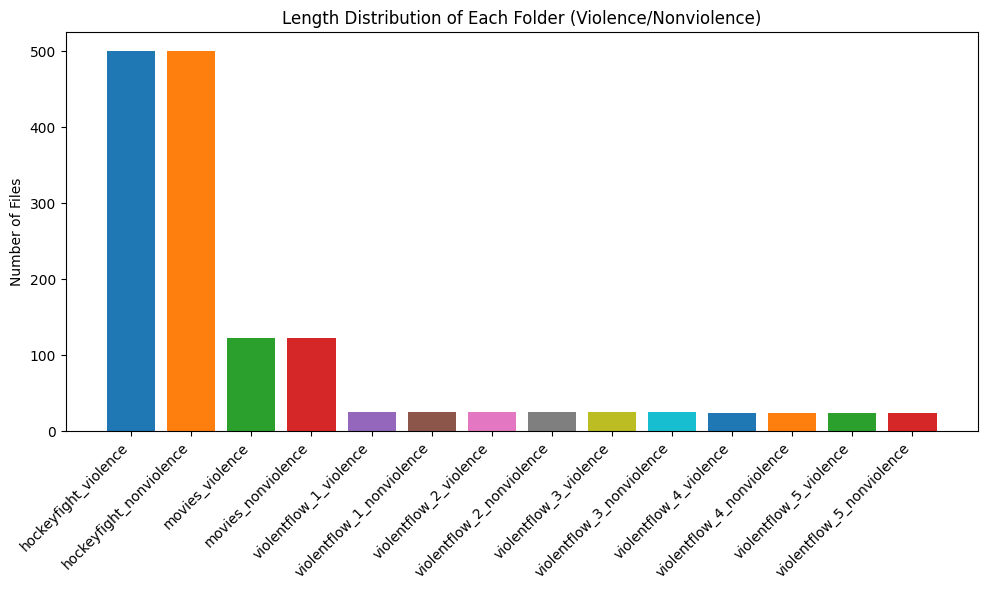

In [ ]:
import os

import matplotlib.pyplot as plt

def get_folder_lengths(base_path):
    lengths = {}
    # For hockeyfight and movies
    for dataset in ['hockeyfight', 'movies']:
        for label in ['violence', 'nonviolence']:
            folder = os.path.join(base_path, dataset, label)
            if os.path.exists(folder):
                files = os.listdir(folder)
                key = f"{dataset}_{label}"
                lengths[key] = [len(os.listdir(folder))]
    # For violentflow
    for i in range(1, 6):
        for label in ['violence', 'nonviolence']:
            folder = os.path.join(base_path, 'violentflow', str(i), label)
            if os.path.exists(folder):
                files = os.listdir(folder)
                key = f"violentflow_{i}_{label}"
                lengths[key] = [len(os.listdir(folder))]
    return lengths

# Assuming all datasets are under 'data' folder
all_lengths = get_folder_lengths('data')

# Plotting
plt.figure(figsize=(10, 6))
for key, value in all_lengths.items():
    plt.bar(key, value[0])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Files')
plt.title('Length Distribution of Each Folder (Violence/Nonviolence)')
plt.tight_layout()
plt.show()in data folder, there is 3 dataset: hockeyfight, movies and violentflow. first consider hockeyfight anf movies, there are inside 2 folder violence and nonviolence. for violentflow, inside folder 1 2 3 4 5 there will be also 2 folder violence and nonviolence. let take a look at their length and draw length distribution of every single folder violence and nonviolence

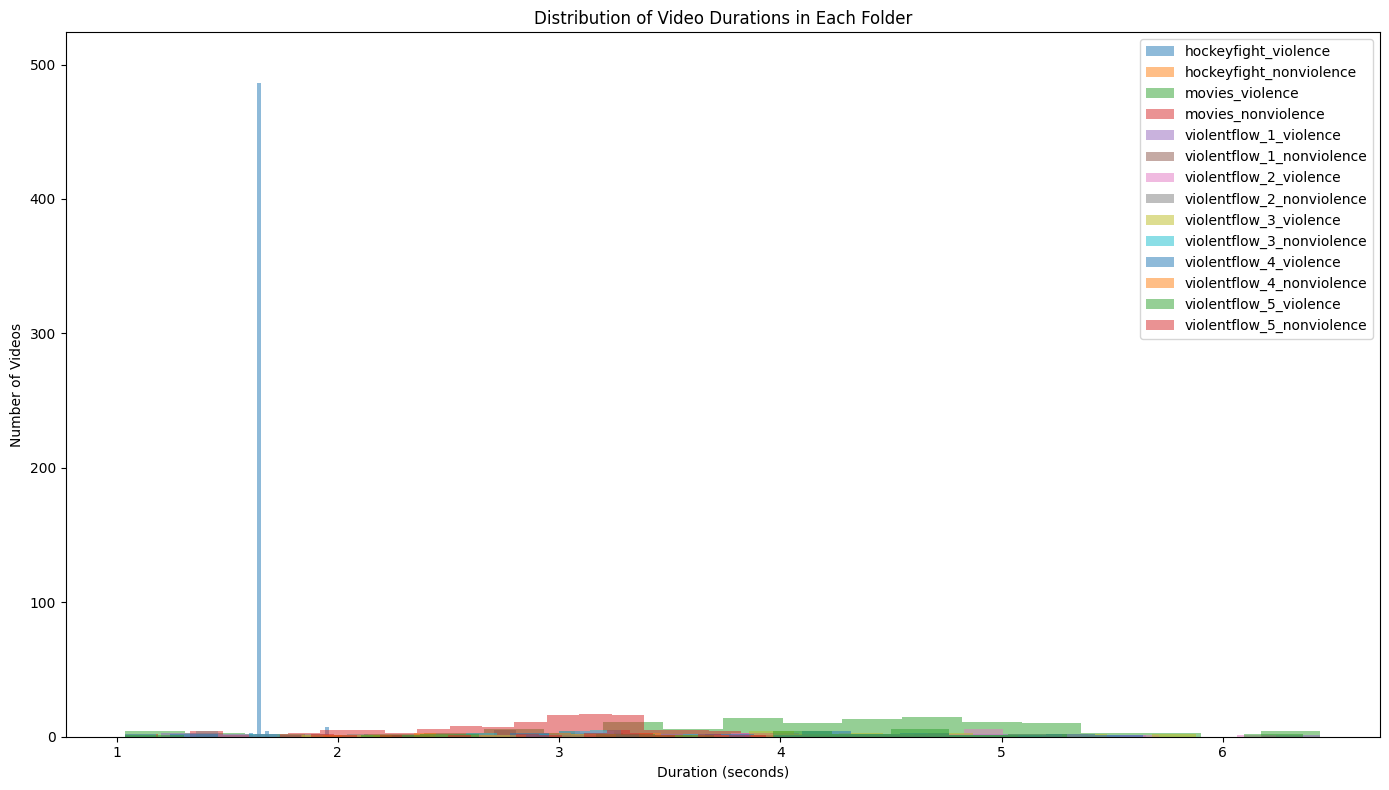

In [6]:
import cv2

# Helper function to get video durations in seconds
def get_video_durations(folder):
    durations = []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath) and fname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
            cap = cv2.VideoCapture(fpath)
            if cap.isOpened():
                fps = cap.get(cv2.CAP_PROP_FPS)
                frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
                if fps > 0:
                    durations.append(frame_count / fps)
            cap.release()
    return durations

# Collect durations for all folders
durations_dict = {}
for dataset in ['hockeyfight', 'movies']:
    for label in ['violence', 'nonviolence']:
        folder = os.path.join(folders[dataset], label)
        if os.path.exists(folder):
            key = f"{dataset}_{label}"
            durations_dict[key] = get_video_durations(folder)

for i in range(1, 6):
    for label in ['violence', 'nonviolence']:
        folder = os.path.join(folders['violentflow'], str(i), label)
        if os.path.exists(folder):
            key = f"violentflow_{i}_{label}"
            durations_dict[key] = get_video_durations(folder)

# Plotting duration distributions
plt.figure(figsize=(14, 8))
for key, durations in durations_dict.items():
    plt.hist(durations, bins=20, alpha=0.5, label=key)
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Videos')
plt.title('Distribution of Video Durations in Each Folder')
plt.legend()
plt.tight_layout()
plt.show()

File counts for hockeyfight folders:
hockeyfight_violence: 500
hockeyfight_nonviolence: 500


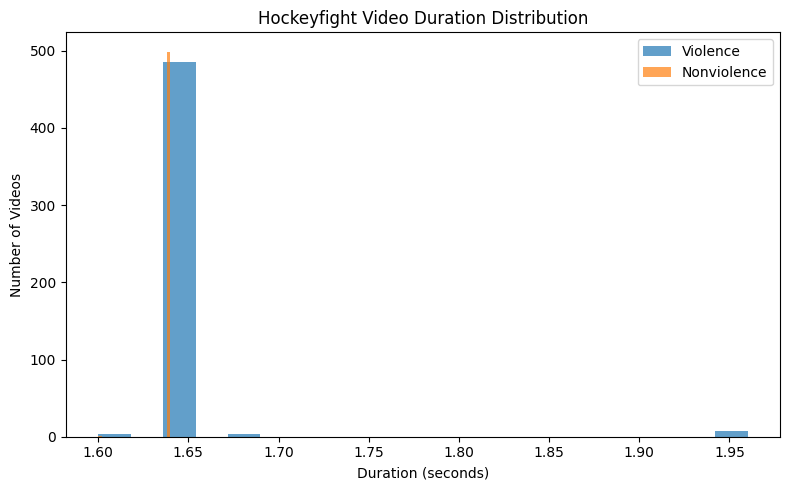

In [7]:
# Filter and display only hockeyfight-related data from all_lengths and durations_dict

# Show file counts for hockeyfight
hockey_lengths = {k: v for k, v in all_lengths.items() if k.startswith('hockeyfight')}
print("File counts for hockeyfight folders:")
for k, v in hockey_lengths.items():
    print(f"{k}: {v[0]}")

# Show duration distributions for hockeyfight
if 'hockeyfight_violence' in durations_dict and 'hockeyfight_nonviolence' in durations_dict:
    plt.figure(figsize=(8, 5))
    plt.hist(durations_dict['hockeyfight_violence'], bins=20, alpha=0.7, label='Violence')
    plt.hist(durations_dict['hockeyfight_nonviolence'], bins=20, alpha=0.7, label='Nonviolence')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Number of Videos')
    plt.title('Hockeyfight Video Duration Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

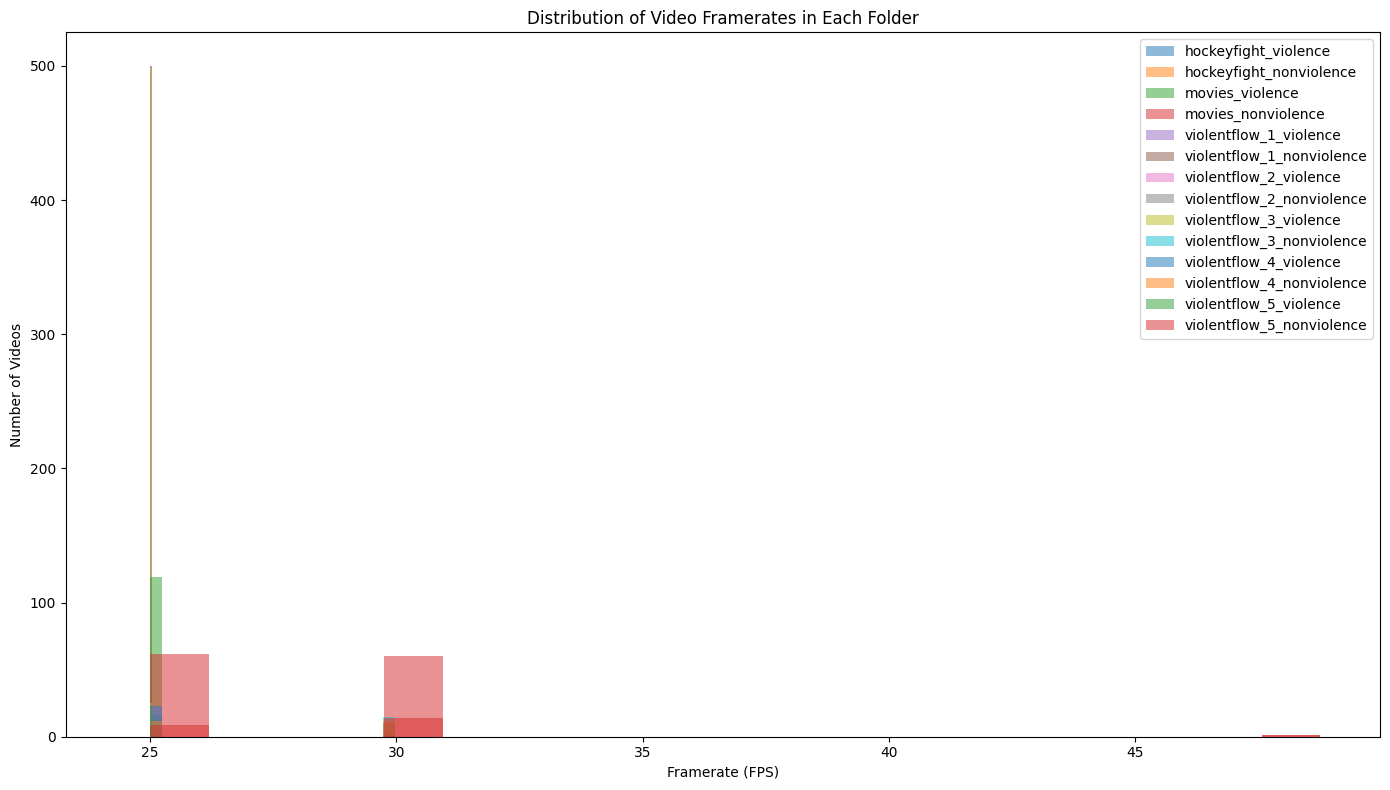

In [ ]:
# Draw distribution of framerate for each folder in durations_dict

framerate_dict = {}

for dataset in ['hockeyfight']:
    for label in ['violence', 'nonviolence']:
        folder = os.path.join(folders[dataset], label)
        if os.path.exists(folder):
            key = f"{dataset}_{label}"
            framerates = []
            for fname in os.listdir(folder):
                fpath = os.path.join(folder, fname)
                if os.path.isfile(fpath) and fname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                    cap = cv2.VideoCapture(fpath)
                    if cap.isOpened():
                        fps = cap.get(cv2.CAP_PROP_FPS)
                        if fps > 0:
                            framerates.append(fps)
                    cap.release()
            framerate_dict[key] = framerates

# for i in range(1, 6):
#     for label in ['violence', 'nonviolence']:
#         folder = os.path.join(folders['violentflow'], str(i), label)
#         if os.path.exists(folder):
#             key = f"violentflow_{i}_{label}"
#             framerates = []
#             for fname in os.listdir(folder):
#                 fpath = os.path.join(folder, fname)
#                 if os.path.isfile(fpath) and fname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
#                     cap = cv2.VideoCapture(fpath)
#                     if cap.isOpened():
#                         fps = cap.get(cv2.CAP_PROP_FPS)
#                         if fps > 0:
#                             framerates.append(fps)
#                     cap.release()
#             framerate_dict[key] = framerates

# Plotting framerate distributions
plt.figure(figsize=(14, 8))
for key, framerates in framerate_dict.items():
    plt.hist(framerates, bins=20, alpha=0.5, label=key)
plt.xlabel('Framerate (FPS)')
plt.ylabel('Number of Videos')
plt.title('Distribution of Video Framerates in Each Folder')
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
import shutil
import os

# Create target folders if they don't exist
ensemble_base = os.path.join('data', 'ensemble')
for label in ['violence', 'nonviolence']:
    target_folder = os.path.join(ensemble_base, label)
    os.makedirs(target_folder, exist_ok=True)

# Copy from data/movies
for label in ['violence', 'nonviolence']:
    src_folder = os.path.join('data', 'movies', label)
    if os.path.exists(src_folder):
        for fname in os.listdir(src_folder):
            src_path = os.path.join(src_folder, fname)
            if os.path.isfile(src_path) and fname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                dst_path = os.path.join(ensemble_base, label, fname)
                shutil.copy2(src_path, dst_path)

# Copy from data/violentflow/1-5
for i in range(1, 6):
    for label in ['violence', 'nonviolence']:
        src_folder = os.path.join('data', 'violentflow', str(i), label)
        if os.path.exists(src_folder):
            for fname in os.listdir(src_folder):
                src_path = os.path.join(src_folder, fname)
                if os.path.isfile(src_path) and fname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                    dst_path = os.path.join(ensemble_base, label, fname)
                    shutil.copy2(src_path, dst_path)

In [1]:
import cv2
import os

video_path = 'pytorch-liteflownet/video/Fight_946.mp4'
output_dir = os.path.join(os.path.dirname(video_path), 'Fight_946_frames')
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_filename = os.path.join(output_dir, f'frame_{frame_idx:05d}.jpg')
    cv2.imwrite(frame_filename, frame)
    frame_idx += 1

cap.release()
print(f"Extracted {frame_idx} frames to {output_dir}")

Extracted 150 frames to pytorch-liteflownet/video/Fight_946_frames


In [5]:
import numpy as np

def read_flow(filename):
    with open(filename, 'rb') as f:
        magic = np.fromfile(f, np.uint8, 4)
        assert magic.tobytes() == b'PIEH'
        width = np.fromfile(f, np.int32, 1)[0]
        height = np.fromfile(f, np.int32, 1)[0]
        data = np.fromfile(f, np.float32, width * height * 2)
        flow = np.reshape(data, (height, width, 2))
        return flow

flow = read_flow('pytorch-liteflownet/out.flo')
print(flow.shape)  # (height, width, 2)

(720, 1280, 2)


In [6]:
def flow_to_image(flow):
    """
    Converts flow into a RGB image.
    Args:
        flow: numpy array of shape (H, W, 2)
    Returns:
        img: numpy array of shape (H, W, 3)
    """
    u = flow[..., 0]
    v = flow[..., 1]
    rad = np.sqrt(u ** 2 + v ** 2)
    ang = np.arctan2(v, u)
    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.float32)
    hsv[..., 0] = (ang + np.pi) / (2 * np.pi)  # Hue
    hsv[..., 1] = 1.0  # Saturation
    hsv[..., 2] = np.clip(rad / np.max(rad), 0, 1)  # Value
    import cv2
    img = cv2.cvtColor((hsv * 255).astype(np.uint8), cv2.COLOR_HSV2RGB)
    return img

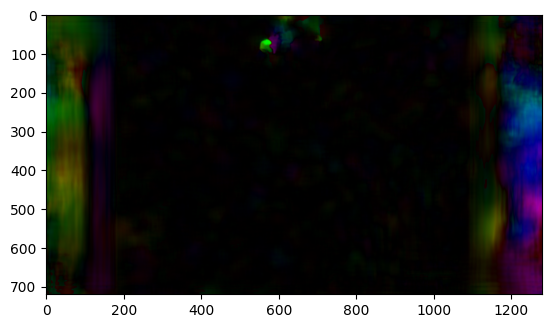

In [7]:
flow_img = flow_to_image(flow)
plt.imshow(flow_img)
plt.show()

In [1]:
import torch
import torch.utils.data as data
import numpy as np
import pandas as pd
import os
import random
from precompute_optflow3d import frame_to_tensor, load_rgb_frames, load_flow_frames
import cv2
import matplotlib.pyplot as plt


In [5]:
def plot_flow_magnitude_histograms_bins(loader, results_dir, max_iter=100):
    """
    Plot two histograms of flow magnitude using fixed bins from 0 to 1 (step 0.05), 
    counting cumulatively to save memory. Stops after max_iter iterations.
    Normalize by the number of videos per label for fairness.
    Saves the plot as 'flow_magnitude_hist_bins.png' in results_dir.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    os.makedirs(results_dir, exist_ok=True)
    bins = np.arange(0, 1.05, 0.05)  # [0, 0.05, ..., 1.0]
    bin_centers = (bins[:-1] + bins[1:]) / 2

    counts_1 = np.zeros(len(bins) - 1, dtype=np.float64)
    counts_0 = np.zeros(len(bins) - 1, dtype=np.float64)
    n_1 = 0
    n_0 = 0
    it = 0

    for (rgb_tensor, flow_tensor), labels in loader:
        flow_np = flow_tensor.numpy()
        labels_np = labels.numpy()
        B, C, T, H, W = flow_np.shape
        for b in range(B):
            flow = np.transpose(flow_np[b], (1, 2, 3, 0))  # [T, H, W, 2]
            mag = np.sqrt(np.square(flow[..., 0]) + np.square(flow[..., 1]))
            mag = np.clip(mag, 0, 1)  # Only consider [0,1] range
            hist, _ = np.histogram(mag, bins=bins)
            if labels_np[b] == 1:
                counts_1 += hist
                n_1 += 1
            else:
                counts_0 += hist
                n_0 += 1
        it += 1
        if it >= max_iter:
            break

    # Normalize by number of videos for fairness
    if n_1 > 0:
        counts_1 = counts_1 / n_1
    if n_0 > 0:
        counts_0 = counts_0 / n_0

    plt.figure(figsize=(10, 5))
    plt.bar(bin_centers - 0.01, counts_0, width=0.02, alpha=0.7, label=f'Label 0 (n={n_0})', color='blue')
    plt.bar(bin_centers + 0.01, counts_1, width=0.02, alpha=0.7, label=f'Label 1 (n={n_1})', color='red')
    plt.xlabel('Flow Magnitude')
    plt.ylabel('Average Count per Video')
    plt.title('Histogram of Optical Flow Magnitude by Label (Normalized per Video)')
    plt.legend()
    plt.tight_layout()
    out_path = os.path.join(results_dir, 'flow_magnitude_hist_bins.png')
    plt.savefig(out_path)
    plt.show()
    plt.close()
    print(f"Saved binned histogram to {out_path}")

In [3]:
from optflow2d_dataset import create_data_loaders, ViolenceDataset

# Load data
split_file = 'data/precomputed/split_info.csv'

dataset = ViolenceDataset(
    split_file=split_file,
    split='train',
    mode='both',
    num_frames=64
)

data_loader = data.DataLoader(
    dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Loaded 1580 train samples in both mode


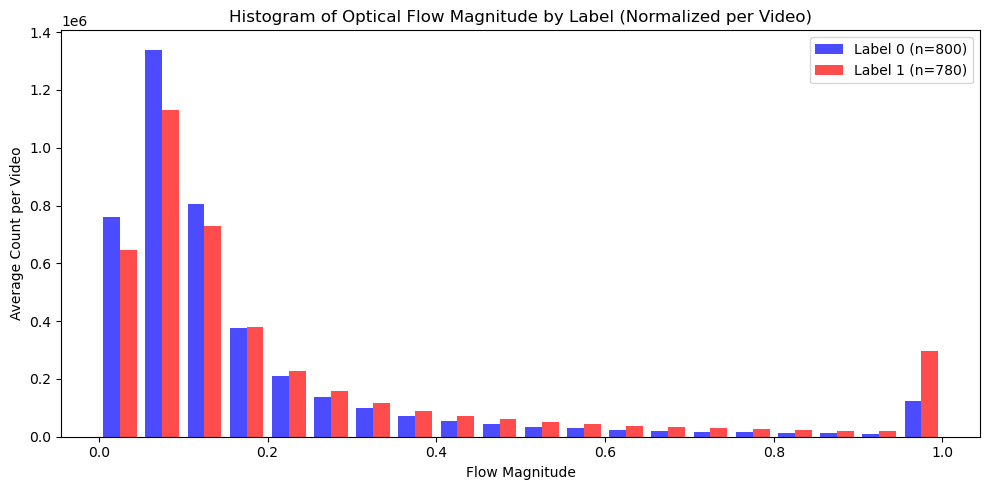

Saved binned histogram to results_dir/flow_magnitude_hist_bins.png


In [7]:
plot_flow_magnitude_histograms_bins(data_loader, results_dir='results_dir', max_iter=100)

In [2]:
import shutil
import os
import tqdm

# Create target folders if they don't exist
ensemble_base = os.path.join('data', 'ensemble')
for label in ['violence', 'nonviolence']:
    target_folder = os.path.join(ensemble_base, label)
    os.makedirs(target_folder, exist_ok=True)


for label in ['violence', 'nonviolence']:
    print(f"Copying files for label: {label}")
    src_folder = os.path.join('data', 'testdataset', label)
    if os.path.exists(src_folder):
        for fname in tqdm.tqdm(os.listdir(src_folder), desc=f"Copying {label} files"):
            src_path = os.path.join(src_folder, fname)
            if os.path.isfile(src_path) and fname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                dst_path = os.path.join(ensemble_base, label, fname)
                shutil.copy2(src_path, dst_path)

Copying files for label: violence


Copying violence files: 100%|██████████| 976/976 [22:16<00:00,  1.37s/it]  


Copying files for label: nonviolence


Copying nonviolence files: 100%|██████████| 1000/1000 [24:30<00:00,  1.47s/it] 
